## Machine Learning Workshop - Crewes 2020: Convolution Neural Networks Explained
In this lab we will look at how Convolutional Neural Networks for classification. \
Based on Chapter 14 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
and Chapter 5 on Fracois Chollet's book, Deep Learning with Python.
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/CNN_Explained.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Add for GPU BEFORE JSON
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
####################################

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Example 1: Fully Connected (Dense) Network vs Convolutional Neural Network.
Compare a Fully Connected Network (FCN) with a Convolution Neural Network (CNN) for the same dataset.

### Example 1 - Step 1 - Loading data 
We will load the MNIST dataset (description [here](https://en.wikipedia.org/wiki/MNIST_database))\
Also, we will normalize the pixel values by substracting the mean and dividing by the standard deviatio.\
Finally we will separate into the train, validation and testing datasets.\
To treat each digit as an image, we need to add the feature axis, 1 in this case because it is black-white image.

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [6]:
#Let us see the array sizes
print('X_train ',X_train.shape)
print('X_valid ',X_valid.shape)
print('X_test  ',X_test.shape)

X_train  (55000, 28, 28, 1)
X_valid  (5000, 28, 28, 1)
X_test   (10000, 28, 28, 1)


### Example 1 - Step 2 - Fully Connected Layer.
For comparison, we will first create a FCN (not the ideal for computer vision)\
These networks do not have translational invariance and therefore need different filters for the same patterns at different locations. \
FCN assume the input has the shape (nbatches, nelements) (2 dimensions) so we need to flatten the images first. 

In [7]:
model1d = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model1d.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [8]:
model1d.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [9]:
history1d=model1d.fit(X_train[:,:,:,0],y_train,epochs=10,validation_data=(X_valid[:,:,:,0],y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 71us/sample - loss: 1.2254 - accuracy: 0.6508 - val_loss: 0.5774 - val_accuracy: 0.8642
Epoch 2/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.5278 - accuracy: 0.8583 - val_loss: 0.3695 - val_accuracy: 0.9106
Epoch 3/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.3936 - accuracy: 0.8895 - val_loss: 0.2987 - val_accuracy: 0.9248
Epoch 4/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.3322 - accuracy: 0.9045 - val_loss: 0.2623 - val_accuracy: 0.9318
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.2948 - accuracy: 0.9146 - val_loss: 0.2382 - val_accuracy: 0.9364
Epoch 6/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.2685 - accuracy: 0.9221 - val_loss: 0.2224 - val_accuracy: 0.9414
Epoch 7/10
55000/55000 [==============================] -

In [10]:
#Let us see the mean square error (MSE)
MSE_DN=model1d.evaluate(X_test[:,:,:,0],y_test)
print("MSE for FCC = ", MSE_DN)

10000/10000 [==============================] - 0s 48us/sample - loss: 127.4879 - accuracy: 0.9365
MSE for FCC =  [127.48794192893357, 0.9365]


In [63]:
def plot_history(history):
    plt.figure(figsize=(8,3))
    plt.subplot(121),plt.plot(history.history['accuracy'],label='training');plt.plot(history.history['val_accuracy'],label='validation');plt.title('accuracy')
    plt.legend()
    plt.subplot(122),plt.plot(history.history['loss'],label='training');plt.plot(history.history['val_loss'],label='validation');plt.title('loss')
    plt.legend()

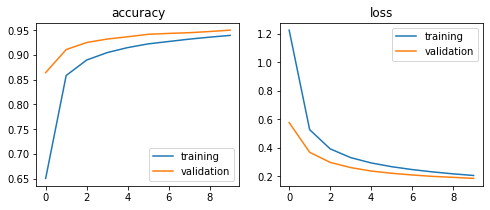

In [58]:
plot_history(history1d)

### Example 1 - Step 3 - Convolutional Network
We start by taking the images (1 channel) and creating 32 feature maps. \
Then we reduce the image size by 2 and double the channels.\
Repeat until we get to the desired image size (3x3) nad map to a dense layer to finish the classification

In [69]:
from tensorflow.keras import layers
from tensorflow.keras import models

model2d = models.Sequential()
model2d.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model2d.add(layers.MaxPooling2D((2, 2)))
model2d.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2d.add(layers.MaxPooling2D((2, 2)))
model2d.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2d.add(layers.Flatten())
model2d.add(layers.Dense(64, activation='relu'))
model2d.add(layers.Dense(10, activation='softmax'))

In [70]:
model2d.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_10 (MaxPooling (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_11 (MaxPooling (None, 5, 5, 64)          0         
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 3, 3, 64)          36928     
_________________________________________________________________
flatten_5 (Flatten)          (None, 576)               0         
_________________________________________________________________
dense_13 (Dense)             (None, 64)               

In [71]:
model2d.compile(optimizer='rmsprop',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [72]:
history2d=model2d.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 6s 104us/sample - loss: 0.1351 - accuracy: 0.9581 - val_loss: 0.0498 - val_accuracy: 0.9894
Epoch 2/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.0458 - accuracy: 0.9862 - val_loss: 0.0515 - val_accuracy: 0.9886
Epoch 3/10
55000/55000 [==============================] - 5s 90us/sample - loss: 0.0341 - accuracy: 0.9899 - val_loss: 0.0558 - val_accuracy: 0.9900
Epoch 4/10
55000/55000 [==============================] - 5s 90us/sample - loss: 0.0274 - accuracy: 0.9919 - val_loss: 0.0641 - val_accuracy: 0.9880
Epoch 5/10
55000/55000 [==============================] - 5s 90us/sample - loss: 0.0221 - accuracy: 0.9936 - val_loss: 0.0607 - val_accuracy: 0.9894
Epoch 6/10
55000/55000 [==============================] - 5s 88us/sample - loss: 0.0206 - accuracy: 0.9945 - val_loss: 0.0532 - val_accuracy: 0.9926
Epoch 7/10
55000/55000 [==============================] 

In [73]:
model2d.evaluate(X_test,y_test)

10000/10000 [==============================] - 1s 54us/sample - loss: 6400.3467 - accuracy: 0.9902


[6400.346702628487, 0.9902]

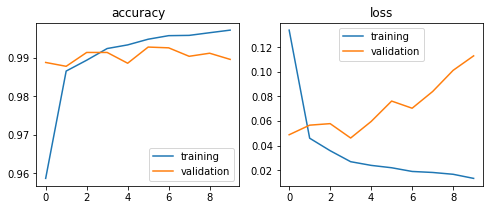

In [74]:
history2d=history
plot_history(history2d)

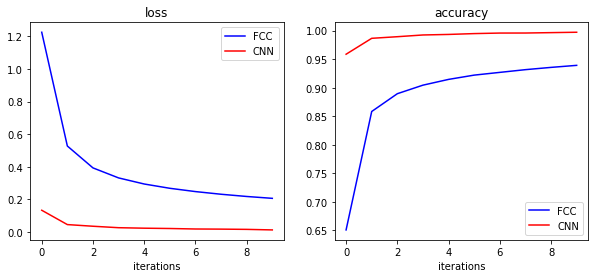

In [75]:
def plot_histories(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_histories(history1d,history2d,'FCC','CNN')

### Example 1 - Step 4 - Comparing predictions

In [76]:
ntest=20;
print(y_test[:ntest])

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [77]:
#notice for the 1D model (FCN) we need to flat the input 
y_predict1d=model1d.predict(X_test[:ntest,:,:,0])
y_predict2d=model2d.predict(X_test[:ntest])

The predict method gives us the probabilities that each instance (20 of them) belongs to each of the 10 classes in the output.

In [78]:
print(y_predict1d.shape)
print(y_predict2d.shape)

(20, 10)
(20, 10)


In [79]:
print(['index','true','pred1d','pred2d'])
[print(i,'\t',y_test[i], '\t',y_predict1d[i,:].argmax(), '\t',y_predict2d[i,:].argmax()) for i in range(0,ntest)];

['index', 'true', 'pred1d', 'pred2d']
0 	 7 	 7 	 7
1 	 2 	 2 	 2
2 	 1 	 1 	 1
3 	 0 	 0 	 0
4 	 4 	 4 	 4
5 	 1 	 1 	 1
6 	 4 	 4 	 4
7 	 9 	 9 	 9
8 	 5 	 6 	 5
9 	 9 	 9 	 9
10 	 0 	 0 	 0
11 	 6 	 6 	 6
12 	 9 	 9 	 9
13 	 0 	 0 	 0
14 	 1 	 1 	 1
15 	 5 	 5 	 5
16 	 9 	 9 	 9
17 	 7 	 7 	 7
18 	 3 	 3 	 5
19 	 4 	 4 	 4


Instance 18 was classified wrongling by the CNN. Let us see it

3 3 5
3 0.54130745 0.36268035


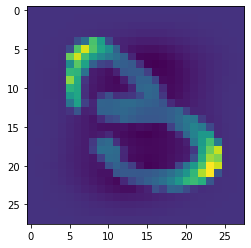

In [81]:
nn=18
print(y_test[nn], y_predict1d[nn,:].argmax(), y_predict2d[nn,:].argmax())
print(y_test[nn], y_predict1d[nn,3], y_predict2d[nn,3])
[plt.imshow(X_test[nn,:,:,0]) for i in range(0,10)];

For home, you can try a bigger layer, for example this. See if you get a better result for the instance 18. 

In [49]:
model2db=keras.models.Sequential([
    keras.layers.Conv2D(64, kernel_size=(7,7), activation='relu', padding='SAME',input_shape=[28,28,1]),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(128, kernel_size=(5,5), activation='relu', padding='SAME'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu', padding='SAME'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')    
])

In [82]:
#model2db.summary()

In [83]:
#model2db.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [84]:
#model2db.evaluate(X_test,y_test)

## Example 2: Transfer learning
In this case we will see a more difficult example. We will try binary classification (easier) but in more complex images.\
Because we want to do this very quickly in the time of this workshop, we will use the fastest possible way.\
We will download a pretrained network (trained in a different problem), and then we will change the last part only.\

### Example 2 - Step 1: Pretrained network
Let us get a pretrained network.

In [85]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

In [86]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 150, 150, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 150, 150, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 150, 150, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 75, 75, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 75, 75, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 75, 75, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 37, 37, 128)       0     

### Example 2 - Step 2: Generate features
Let us use the pretrained networks to extract the main features from the images.

In [113]:
image='/home/dtrad/data/dogs-cats/cats_and_dogs_small/train/cats/cat.0.jpg'

In [98]:
import os
base_dir = '/home/dtrad/data/dogs-cats/cats_and_dogs_small'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

Found 2000 images belonging to 2 classes.
class [0.]
class [0.]
class [0.]
class [1.]


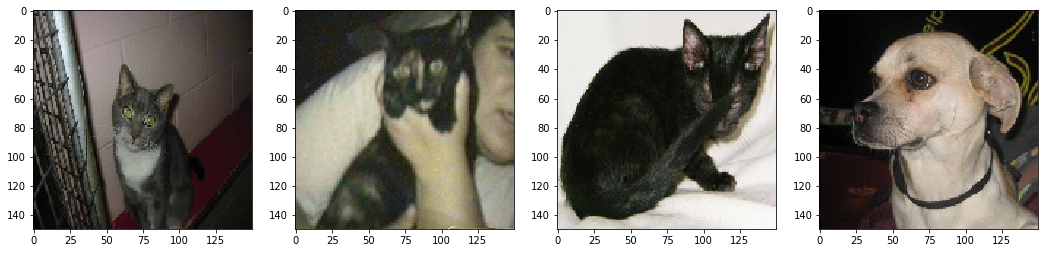

In [151]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)
generator=datagen.flow_from_directory(train_dir, target_size=(150,150), batch_size=1, class_mode='binary')
count=0
plt.figure(figsize=(18,18))
for input_batch, labels_batch in generator:
    plt.subplot(141+count),plt.imshow(input_batch[0,:,:,:])
    count+=1
    print('class',labels_batch)
    if (count ==4):
        break


In [152]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch)
        features[i * batch_size : (i + 1) * batch_size] = features_batch
        labels[i * batch_size : (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            # Note that since generators yield data indefinitely in a loop,
            # we must `break` after every image has been seen once.
            break
    return features, labels

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Notice the output of the last conv_base network has shape (None, 4, 4, 512). That means that produces 512 features, each of size 4x4.\
The first dimension is free (number of samples). 

In [153]:
print(train_features.shape, train_labels.shape)

(2000, 4, 4, 512) (2000,)


Text(0.5, 1.0, 'one feature from the last layer')

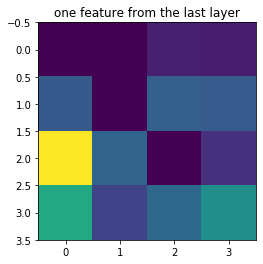

In [154]:
plt.imshow(train_features[0,:,:,0]);
plt.title('one feature from the last layer')

In [155]:
print(train_labels[:10])

[1. 0. 0. 1. 1. 1. 0. 1. 0. 1.]


### Example 2 - Step 3: Classification
Use the extraced features to classify the image.\
We need to map the train_features to a vector.



In [156]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

In [157]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(lr=2e-5),
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(train_features, train_labels,
                    epochs=30,
                    batch_size=20,
                    validation_data=(validation_features, validation_labels))

Train on 2000 samples, validate on 1000 samples
Epoch 1/30
2000/2000 [==============================] - 1s 447us/sample - loss: 0.5795 - acc: 0.6910 - val_loss: 0.4477 - val_acc: 0.8140
Epoch 2/30
2000/2000 [==============================] - 0s 179us/sample - loss: 0.4270 - acc: 0.8000 - val_loss: 0.3653 - val_acc: 0.8530
Epoch 3/30
2000/2000 [==============================] - 0s 160us/sample - loss: 0.3622 - acc: 0.8485 - val_loss: 0.3234 - val_acc: 0.8720
Epoch 4/30
2000/2000 [==============================] - 0s 156us/sample - loss: 0.3224 - acc: 0.8645 - val_loss: 0.3007 - val_acc: 0.8840
Epoch 5/30
2000/2000 [==============================] - 0s 156us/sample - loss: 0.2864 - acc: 0.8870 - val_loss: 0.2847 - val_acc: 0.8890
Epoch 6/30
2000/2000 [==============================] - 0s 154us/sample - loss: 0.2671 - acc: 0.8900 - val_loss: 0.2731 - val_acc: 0.8880
Epoch 7/30
2000/2000 [==============================] - 0s 153us/sample - loss: 0.2491 - acc: 0.8975 - val_loss: 0.2673 - va

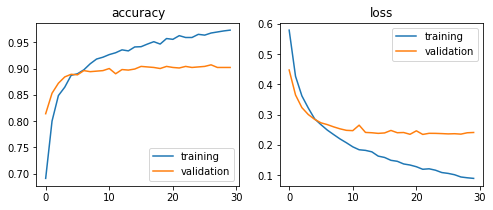

In [159]:
def plot_history(history):
    plt.figure(figsize=(8,3))
    plt.subplot(121),plt.plot(history.history['acc'],label='training');plt.plot(history.history['val_acc'],label='validation');plt.title('accuracy')
    plt.legend()
    plt.subplot(122),plt.plot(history.history['loss'],label='training');plt.plot(history.history['val_loss'],label='validation');plt.title('loss')
    plt.legend()
plot_history(history)

## Example 3: visualizing feature maps
Now we will instect feature maps.